In [33]:
import os
from pathlib import Path
from abc import ABC
from dataclasses import dataclass
from enum import Enum
from typing import List, Optional, Dict, Callable
from collections import defaultdict, Counter
from fogvis.db import Database
from fogvis.common.math import VectorContainer3D
from contextlib import closing
import logging

import random
DB_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir, "import", "db")))
if not os.path.isfile(os.path.join(DB_PATH, "database.sqlite3")):
    raise FileNotFoundError(f"Database file not found: {p / 'database.sqlite3'}")
db : Database = Database(DB_PATH)

In [34]:
@dataclass
class MarchedVisibility: 
    mean : float
    median : float 
    minimum : float
    num_rays : int

@dataclass
class ComplexVisibility:
    including_invalid_rays : Optional[MarchedVisibility] = None
    excluding_invalid_rays : Optional[MarchedVisibility] = None

@dataclass
class ImageVisibility: 
    vis_simple : Optional[float] = None
    vis_marched : Optional[ComplexVisibility] = None 

class TimeOfDay(Enum):
    MORNING = "morning"
    NOON = "noon"
    EVENING = "evening"
    UNKNOWN = "unknown"

def time_of_day_from_direction(direction_json: str) -> TimeOfDay:
    """
    Map a light direction vector to one of three times of day.
    The database currently contains three unique directional lights:
        (0, -1, 0) -> noon / overhead sun
        (0, 0, -1) -> morning / sun from the -z direction
        (0, 0, 1)  -> evening / sun from the +z direction
    """
    direction = VectorContainer3D.from_json(direction_json)
    x, y, z = direction.x, direction.y, direction.z
    if abs(y + 1.0) < 1e-6 and x == 0.0 and z == 0.0:
        return TimeOfDay.NOON
    if abs(z + 1.0) < 1e-6 and x == 0.0 and y == 0.0:
        return TimeOfDay.MORNING
    if abs(z - 1.0) < 1e-6 and x == 0.0 and y == 0.0:
        return TimeOfDay.EVENING
    return TimeOfDay.UNKNOWN

@dataclass
class RetreivedImageData:
    image_name : str
    fog_id : int
    vis_values : ImageVisibility
    time_of_day : TimeOfDay
    import_dir : Path

@dataclass
class FogImage:
    image_path: str
    visibility: float
    time_of_day: TimeOfDay

@dataclass
class Dataset:
    images: List[FogImage]

class Experiment(ABC):
    def __init__(self, dbs: List[Database]) -> None:
        self.dbs: List[Database] = dbs

    def get_datasets(self) -> List[Dataset]:
        """Gathers a list of datasets to be used for training.
        Each item refers to a different set of data to be used in training a
        seperate instance of a model

        Returns:
            list: _description_
        """
        pass

    def get_validation_dataset(self) -> Dataset:
        """Validation set held out from the training datasets.

        Implementations must guarantee that no image returned here also
        appears in any dataset returned by ``get_datasets``.
        """
        pass

def get_fog_images(
    db: Database, fog_type_name: str, scene_name: str
) -> list[RetreivedImageData]:
    result: list[RetreivedImageData] = []
    
    with db as con:
        ctx = con.cursor()
        sql: str = """SELECT image.fileName, fog.id AS fogID, visibility_distance.distanceType, visibility_distance.value, visibility_distance.average, visibility_distance.median, visibility_distance.minimum, visibility_distance.rayCount, light.virtualDirection FROM image
        INNER JOIN view ON view.colorImageID = image.id
        INNER JOIN camera ON view.cameraID = camera.id
        INNER JOIN scene ON view.sceneID = scene.id
        INNER JOIN environment ON view.environmentID = environment.id
        INNER JOIN fog ON environment.fogID = fog.id
        INNER JOIN fog_type ON fog.typeID = fog_type.id
        INNER JOIN environment_light ON environment.id = environment_light.environmentID
        INNER JOIN light ON environment_light.lightID = light.id
        INNER JOIN visibility_distance ON visibility_distance.viewID = view.id
            WHERE fog_type.name = ? AND
            scene.name = ? 
        """
        parms = (fog_type_name, scene_name)
        ctx.execute(sql, parms)
        res = ctx.fetchall()
        if len(res) == 0:
            return []

        visibilities : Dict[str, ImageVisibility] = {}
        time_of_days : Dict[str, TimeOfDay] = {}
        fog_ids : Dict[str, int] = {}

        for r in res:
            name : str = r[0]
            fog_id : int = r[1]
            mean : Optional[float] = None
            median : Optional[float] = None
            min : Optional[float] = None
            ray_count : Optional[int] = None
            direction_json : str = r[8]

            if name not in fog_ids:
                fog_ids[name] = fog_id
            else:
                if fog_ids[name] != fog_id:
                    time_of_days[name] = TimeOfDay.UNKNOWN

            if name not in time_of_days:
                time_of_days[name] = time_of_day_from_direction(direction_json)
            else:
                if time_of_days[name] != time_of_day_from_direction(direction_json):
                    time_of_days[name] = TimeOfDay.UNKNOWN

            if r[4] is not None: 
                mean = float(r[4])
            if r[5] is not None: 
                median = float(r[5])
            if r[6] is not None: 
                min = float(r[6])
            if r[7] is not None: 
                ray_count = int(r[7])

            if name not in visibilities: 
                visibilities[name] = ImageVisibility(None, None)
            
            if r[2] == "simple": 
                visibilities[name].vis_simple = float(r[3])
            elif r[2] == "ray_excluding_invalid": 
                if mean is not None and median is not None and min is not None and ray_count is not None: 
                    if visibilities[name].vis_marched is None: 
                        visibilities[name].vis_marched = ComplexVisibility(excluding_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count))
                    else:
                        visibilities[name].vis_marched.excluding_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count)

            elif r[2] == "ray_including_invalid":
                if (mean is not None and median is not None and min is not None and ray_count is not None): 
                    if visibilities[name].vis_marched is None:
                        visibilities[name].vis_marched = ComplexVisibility(including_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count))
                    else:
                        visibilities[name].vis_marched.including_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count)
                else:
                    raise Exception(f"Failed to parse distance metrics for image. This should not happen.")

        for file_name in visibilities: 
            result.append(RetreivedImageData(image_name=file_name, fog_id=fog_ids[file_name], vis_values=visibilities[file_name], time_of_day=time_of_days[file_name], import_dir=db.import_dir))

    return result

RetrievedFilter = Callable[[List[RetreivedImageData]], List[RetreivedImageData]]
FogConverter = Callable[[RetreivedImageData], FogImage]

def filter_has_simple_visibility(data: List[RetreivedImageData]) -> List[RetreivedImageData]:
    return [d for d in data if d.vis_values.vis_simple is not None]

def filter_has_marched_excluding_invalid(data: List[RetreivedImageData]) -> List[RetreivedImageData]:
    return [
        d for d in data
        if d.vis_values.vis_marched is not None and d.vis_values.vis_marched.excluding_invalid_rays is not None
    ]

def filter_has_marched_including_invalid(data : List[RetreivedImageData]) -> List[RetreivedImageData]: 
    return [
        d for d in data
        if d.vis_values.vis_marched is not None and d.vis_values.vis_marched.including_invalid_rays is not None
    ]

def filter_only_noon(data : List[RetreivedImageData]) -> List[RetreivedImageData]: 
    return [
        d for d in data
        if d.time_of_day == TimeOfDay.NOON
    ]

def balance_by_time_of_day_by_image(seed: Optional[int] = None) -> RetrievedFilter:
    """
    Randomly downsample each time-of-day bucket so all buckets have the same number of images.
    """
    def _filter(data: List[RetreivedImageData]) -> List[RetreivedImageData]:
        if seed is not None:
            random.seed(seed)
        by_tod = defaultdict(list)
        for d in data:
            by_tod[d.time_of_day].append(d)
        if not by_tod:
            return []
        target = min(len(items) for items in by_tod.values())
        balanced : List[RetreivedImageData] = []
        for items in by_tod.values():
            if len(items) <= target:
                balanced.extend(items)
            else:
                balanced.extend(random.sample(items, target))
        return balanced
    return _filter

def balance_by_time_of_day_by_fog_body(seed: Optional[int] = None) -> RetrievedFilter:
    """
    Ensure each time-of-day bucket contains images from the same set of fog bodies.
    Only fog bodies that appear under every time of day are kept.
    """
    def _filter(data: List[RetreivedImageData]) -> List[RetreivedImageData]:
        if seed is not None:
            random.seed(seed)
        by_tod = defaultdict(lambda: defaultdict(list))
        for d in data:
            by_tod[d.time_of_day][d.fog_id].append(d)
        if not by_tod:
            return []
        common_bodies = set.intersection(*(set(bodies.keys()) for bodies in by_tod.values()))
        if not common_bodies:
            return []
        balanced : List[RetreivedImageData] = []
        for tod, bodies in by_tod.items():
            for body in common_bodies:
                images = bodies[body]
                balanced.extend(images)
        return balanced
    return _filter

def build_dataset(
    dbs: List[Database],
    fog_type_name: str,
    scene_name: str,
    filters: List[RetrievedFilter],
    converter: FogConverter,
) -> Dataset:
    raw: List[RetreivedImageData] = []
    for db in dbs:
        raw.extend(get_fog_images(db, fog_type_name, scene_name))
    for f in filters:
        raw = f(raw)
    return Dataset(images=[converter(d) for d in raw])


METERS_PER_MILE = 1609.344
NUM_CLASSES = 16


def split_validation_by_mile(
    dataset: Dataset,
    val_fraction: float = 0.05,
    num_classes: int = NUM_CLASSES,
    seed: Optional[int] = None,
) -> tuple[Dataset, Dataset]:
    """
    Split a Dataset into (train, validation) holding out ``val_fraction`` of
    the images for validation, drawn with an equal number of samples from
    each rounded-mile visibility class in [0, num_classes).

    The validation set is class-balanced: every present mile class
    contributes the same number of images
    (``per_class = floor(val_fraction * N / #present_classes)``). A class
    with fewer than ``per_class`` images contributes all of its images, so
    the validation set may be slightly smaller than ``val_fraction * N`` when
    a class is under-populated. Images whose rounded-mile class falls
    outside [0, num_classes) stay entirely in the training set.
    """
    rng = random.Random(seed)

    by_class: Dict[int, List[FogImage]] = defaultdict(list)
    for img in dataset.images:
        vis_class = round(float(img.visibility) / METERS_PER_MILE)
        if 0 <= vis_class < num_classes:
            by_class[vis_class].append(img)

    present = sorted(by_class.keys())
    if not present:
        return dataset, Dataset(images=[])

    per_class = max(1, round(val_fraction * len(dataset.images)) // len(present))

    val_images: List[FogImage] = []
    for cl in present:
        bucket = by_class[cl]
        take = min(per_class, len(bucket))
        val_images.extend(rng.sample(bucket, take))

    # Remove the held-out images from training. Identity comparison is safe
    # here because every FogImage in dataset.images is a distinct object.
    val_ids = set(id(img) for img in val_images)
    train_images = [img for img in dataset.images if id(img) not in val_ids]
    return Dataset(images=train_images), Dataset(images=val_images)

def linear_converter(data: RetreivedImageData) -> FogImage:
    return FogImage(
        image_path=os.path.join(data.import_dir, data.image_name),
        visibility=float(data.vis_values.vis_simple),
        time_of_day=data.time_of_day,
    )

def exponential_converter(data: RetreivedImageData) -> FogImage:
    return FogImage(
        image_path=os.path.join(data.import_dir, data.image_name),
        visibility=float(data.vis_values.vis_simple),
        time_of_day=data.time_of_day,
    )

def marched_converter_excluding_invalid_rays(data: RetreivedImageData) -> FogImage:
    return FogImage(
        image_path=os.path.join(data.import_dir, data.image_name),
        visibility=float(data.vis_values.vis_marched.excluding_invalid_rays.mean),
        time_of_day=data.time_of_day,
    )

def marched_converter_including_invalid_rays(data: RetreivedImageData) -> FogImage:
    return FogImage(
        image_path=os.path.join(data.import_dir, data.image_name),
        visibility=float(data.vis_values.vis_marched.including_invalid_rays.mean),
        time_of_day=data.time_of_day,
    )

def marched_converter_including_invalid_rays_median(data : RetreivedImageData) -> FogImage: 
    return FogImage(
        image_path=os.path.join(data.import_dir, data.image_name),
        visibility=float(data.vis_values.vis_marched.including_invalid_rays.median),
        time_of_day=data.time_of_day,
    )

class Basic_Synthetic_Quality(Experiment):
    def __init__(
        self,
        dbs: List[Database],
        val_fraction: float = 0.05,
        num_classes: int = NUM_CLASSES,
        seed: Optional[int] = None,
    ) -> None:
        super().__init__(dbs)
        self.val_fraction = val_fraction
        self.num_classes = num_classes
        self.seed = seed
        self._splits: Optional[tuple[List[Dataset], Dataset]] = None

    def _build_splits(self) -> tuple[List[Dataset], Dataset]:
        # (fog_type, filters, converter) for each per-fog-type training set.
        specs = [
            ("linear", [filter_has_simple_visibility], linear_converter),
            ("exponential", [filter_has_simple_visibility], exponential_converter),
            ("marched", [filter_has_marched_excluding_invalid], marched_converter_including_invalid_rays),
        ]
        train_datasets: List[Dataset] = []
        val_images: List[FogImage] = []
        for idx, (fog_type, filters, converter) in enumerate(specs):
            full = build_dataset(
                self.dbs, fog_type, "berthoud_pass_co",
                filters=filters,
                converter=converter,
            )
            # Hold out val_fraction of each fog type, balanced per mile.
            fog_seed = None if self.seed is None else self.seed + idx
            train_ds, val_ds = split_validation_by_mile(
                full,
                val_fraction=self.val_fraction,
                num_classes=self.num_classes,
                seed=fog_seed,
            )
            train_datasets.append(train_ds)
            val_images.extend(val_ds.images)
        return train_datasets, Dataset(images=val_images)

    def _ensure_splits(self) -> tuple[List[Dataset], Dataset]:
        if self._splits is None:
            self._splits = self._build_splits()
        return self._splits

    def get_datasets(self) -> List[Dataset]:
        # Training datasets with the held-out validation images removed.
        return self._ensure_splits()[0]

    def get_validation_dataset(self) -> Dataset:
        # Combined validation set: 5% of each fog type, balanced per mile.
        return self._ensure_splits()[1]

experiment : Basic_Synthetic_Quality = Basic_Synthetic_Quality([db])
datasets = experiment.get_datasets()
validation = experiment.get_validation_dataset()


## Demo Stuff
This code is just for showing what is in the dataset and making sure paths are correct

### Helpers

In [35]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import math
from collections import Counter

def display_image(img : FogImage) -> None: 
    i = mpimg.imread(img.image_path)
    plt.imshow(i)
    plt.axis('off')
    plt.title(f'Distance: {img.visibility} meters')
    plt.show()
    

def plot_visibility_classes(dataset, title : str) -> None:
    """
    Plot a bar graph showing the number of images in each visibility class.

    Each class is the floored number of miles of visibility.
    Example:
        0.3 miles -> class 0
        1.9 miles -> class 1
        5.0 miles -> class 5

    Parameters
    ----------
    dataset : Dataset
        A Dataset object containing a list of FogImage objects.
    """

    METERS_PER_MILE = 1609.344

    visibility_classes = []

    for image in dataset.images:
        try:
            vis_meters = float(image.visibility)
        except ValueError:
            print(f"Skipping invalid visibility value: {image.visibility}")
            continue

        vis_miles = vis_meters / METERS_PER_MILE
        vis_class = round(vis_miles)

        visibility_classes.append(vis_class)

    class_counts = Counter(visibility_classes)

    if not class_counts:
        print("No valid visibility distances found.")
        return

    # Sort classes by visibility distance
    counts = []
    classes = []
    counter = 0
    for cl in sorted(class_counts.keys()):
        if counter == 16:
            break

        classes.append(cl) 
        counter += 1

    for cl in classes:
        counts.append(class_counts[cl])

    plt.figure(figsize=(10, 6))
    plt.bar(classes, counts)

    plt.xlabel("Visibility Class, Rounded")
    plt.ylabel("Number of Images")
    plt.title(title)

    plt.xticks(classes)
    plt.grid(axis="y", alpha=0.3)

    plt.show()


In [36]:
METERS_PER_MILE = 1609.344
NUM_CLASSES = 16
def _count_visibility_classes(dataset: Dataset) -> Counter:
    """Count images per rounded-mile visibility class (0–15)."""
    counts: Counter = Counter()
    for img in dataset.images:
        vis_miles = float(img.visibility) / METERS_PER_MILE
        vis_class = round(vis_miles)
        if 0 <= vis_class < NUM_CLASSES:
            counts[vis_class] += 1
    return counts


import pandas as pd


def visibility_class_table(datasets: Dict[str, Dataset]) -> pd.DataFrame:
    """
    Build a table of per-class image counts across fog techniques.

    Rows are rounded-mile visibility classes (0-15) plus a trailing Total row;
    columns are the fog-type labels. Intended for the dataset paper, where exact
    per-class counts matter more than a bar chart (whose shared scale dwarfs the
    smaller datasets and whose value labels overlap).

    Parameters
    ----------
    datasets : dict of {label: Dataset}
        e.g. {"Linear": linear_ds, "Exponential": exp_ds, "Marched": marched_ds}
    """
    classes = list(range(NUM_CLASSES))
    columns = {}
    for name, dataset in datasets.items():
        class_counts = _count_visibility_classes(dataset)
        columns[name] = [class_counts.get(c, 0) for c in classes]

    df = pd.DataFrame(columns, index=classes)
    df.index.name = "class"

    totals = pd.DataFrame(df.sum(numeric_only=True)).T
    totals.index = ["Total"]
    df = pd.concat([df, totals])
    return df

### Datasets

Linear Images

In [37]:
lin = datasets[0]
exp = datasets[1]
marched = datasets[2]

In [38]:
print(f"Num Linear Images: {len(lin.images)}")
print(f"Num Exp Images: {len(exp.images)}")
print(f"Num Marched Images: {len(marched.images)}")

Num Linear Images: 5144
Num Exp Images: 38484
Num Marched Images: 133975


In [39]:
df = visibility_class_table({
    "linear": datasets[0],
    "exponential": datasets[1],
    "marched": datasets[2],
})

REPO_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir)))
out_dir = REPO_ROOT / "output"
out_dir.mkdir(parents=True, exist_ok=True)
csv_path = out_dir / "visibility_classes.csv"
df.to_csv(csv_path, index=True)

print(f"Wrote {csv_path.resolve()}")
df

Wrote E:\Repos\FoggyVision\output\visibility_classes.csv


,linear,exponential,marched
0,164,2214,16243
1,344,2034,4198
2,344,2394,10386
3,164,2484,12155
4,344,2574,10950
5,344,2484,8485
6,164,2574,8879
7,344,2574,8328
8,344,2574,8062
9,164,2574,7203


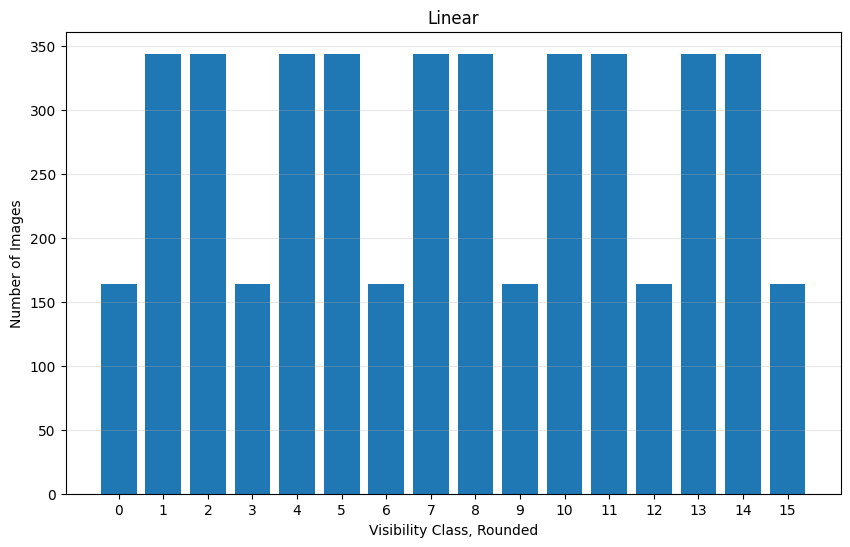

In [40]:
plot_visibility_classes(lin, "Linear")

Exponential Images

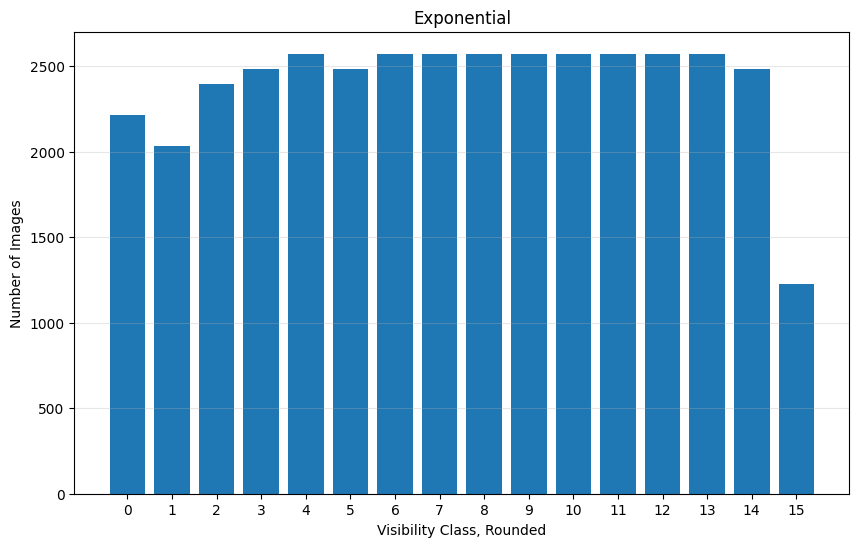

In [41]:
plot_visibility_classes(exp, "Exponential")

Marched

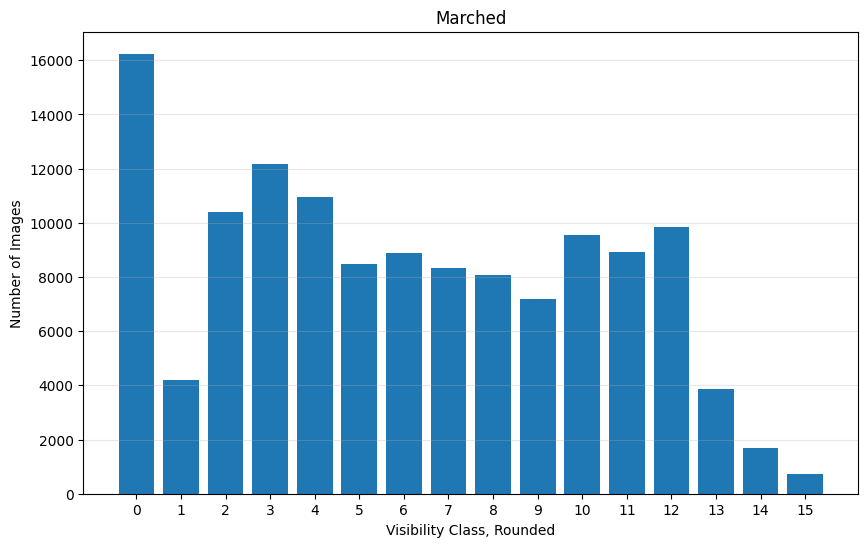

In [42]:
plot_visibility_classes(marched, "Marched")

## Distance Metric Analysis: Mean vs Median (incl. invalid rays)

Supporting the choice of label for the marched training data: the **mean** of the ray-including-invalid distance. The same marched images are labeled two ways - by the mean and by the median of the including-invalid-rays metric - and compared per visibility class. Bins 0..9 are listed individually; any image whose rounded-mile class is 10 or above is folded into a single "10+" bucket.

In [ ]:
SCENE = "berthoud_pass_co"

# Same marched images, two labelings of the ray-including-invalid distance metric.
# marched_converter_including_invalid_rays uses the mean; the _median variant uses the median.
marched_mean = build_dataset(
    [db], "marched", SCENE,
    filters=[filter_has_marched_including_invalid],
    converter=marched_converter_including_invalid_rays,
)

marched_median = build_dataset(
    [db], "marched", SCENE,
    filters=[filter_has_marched_including_invalid],
    converter=marched_converter_including_invalid_rays_median,
)

print(f"Marched images (mean label):   {len(marched_mean.images)}")
print(f"Marched images (median label): {len(marched_median.images)}")

### Grouped bar chart: mean vs median

Per visibility class, the number of marched images when labeled by the mean vs the median of the including-invalid-rays distance.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

METERS_PER_MILE = 1609.344
MAX_MILE_CLASS = 9  # individual bins 0..9; anything 10 and above collapses into "10+"


def count_visibility_classes_10plus(dataset: Dataset) -> Counter:
    """Count images per rounded-mile visibility class with a 10+ catch-all.

    Bins 0..MAX_MILE_CLASS are kept individually; any image whose rounded-mile
    class exceeds MAX_MILE_CLASS is folded into a single "10+" bucket (keyed by
    the string "10+"). Negative classes are excluded, so every non-negative
    image is counted.
    """
    counts: Counter = Counter()
    for img in dataset.images:
        vis_class = round(float(img.visibility) / METERS_PER_MILE)
        if vis_class < 0:
            continue
        if vis_class > MAX_MILE_CLASS:
            vis_class = "10+"
        counts[vis_class] += 1
    return counts


def _class_labels_10plus():
    return list(range(MAX_MILE_CLASS + 1)) + ["10+"]


def plot_grouped_visibility_classes(ds_mean: Dataset, ds_median: Dataset, title: str) -> None:
    """Grouped bar chart of per-class image counts for two labelings."""
    labels = _class_labels_10plus()
    mean_counts = [count_visibility_classes_10plus(ds_mean).get(c, 0) for c in labels]
    median_counts = [count_visibility_classes_10plus(ds_median).get(c, 0) for c in labels]

    x = np.arange(len(labels))
    width = 0.4

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - width / 2, mean_counts, width,
           label="Mean (incl. invalid rays)", color="#3a6ea5")
    ax.bar(x + width / 2, median_counts, width,
           label="Median (incl. invalid rays)", color="#e07b39")

    ax.set_xlabel("Visibility Class (rounded miles)")
    ax.set_ylabel("Number of Images")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in labels])
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_grouped_visibility_classes(
    marched_mean, marched_median,
    "Marched Fog: Images per Visibility Class - Mean vs Median (incl. invalid rays)",
)

### Per-class counts table

Exact counts for the chart above, written to `output/distance_metric_classes.csv`.

In [ ]:
import pandas as pd


def _single_label_table(counts: Counter, labels, column: str) -> pd.DataFrame:
    """One-column per-class count table with a Total row."""
    df = pd.DataFrame(
        {column: [counts.get(c, 0) for c in labels]},
        index=[str(c) for c in labels],
    )
    df.index.name = "class"
    totals = pd.DataFrame(df.sum(numeric_only=True)).T
    totals.index = ["Total"]
    df = pd.concat([df, totals])
    df.index.name = "class"  # concat drops the index name; restore it
    return df


def visibility_class_table_mean_median(ds_mean: Dataset, ds_median: Dataset) -> pd.DataFrame:
    """Per-class image counts for the two labelings, with a Total row."""
    labels = _class_labels_10plus()
    cm = count_visibility_classes_10plus(ds_mean)
    cd = count_visibility_classes_10plus(ds_median)
    df_mean_median = pd.DataFrame(
        {
            "Mean (incl. invalid)": [cm.get(c, 0) for c in labels],
            "Median (incl. invalid)": [cd.get(c, 0) for c in labels],
        },
        index=[str(c) for c in labels],
    )
    df_mean_median.index.name = "class"
    totals = pd.DataFrame(df_mean_median.sum(numeric_only=True)).T
    totals.index = ["Total"]
    df_mean_median = pd.concat([df_mean_median, totals])
    df_mean_median.index.name = "class"
    return df_mean_median


labels = _class_labels_10plus()
cm = count_visibility_classes_10plus(marched_mean)
cd = count_visibility_classes_10plus(marched_median)

df_mean = _single_label_table(cm, labels, "Number of Images")
df_median = _single_label_table(cd, labels, "Number of Images")
df_mean_median = visibility_class_table_mean_median(marched_mean, marched_median)

REPO_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir)))
out_dir = REPO_ROOT / "output"
out_dir.mkdir(parents=True, exist_ok=True)

# marched_mean/marched_median are built with filter_has_marched_including_invalid,
# so these counts include invalid rays.
RAY_LABEL = "includes"

csv_paths = {
    "combined": out_dir / f"distance_metric_classes_{RAY_LABEL}.csv",
    "mean": out_dir / f"distance_metric_classes_mean_{RAY_LABEL}.csv",
    "median": out_dir / f"distance_metric_classes_median_{RAY_LABEL}.csv",
}
df_mean_median.to_csv(csv_paths["combined"], index=True)
df_mean.to_csv(csv_paths["mean"], index=True)
df_median.to_csv(csv_paths["median"], index=True)

for p in csv_paths.values():
    print(f"Wrote {p.resolve()}")
df_mean_median

## Cross fog-type class breakdown (marched = mean, incl. invalid rays)

Per visibility class, the number of images for each fog type on the full
(pre-validation-split) datasets. Linear and exponential use their simple
visibility distance; marched uses the **mean of the including-invalid-rays**
distance. Bins 0..9 are individual and 10+ is the catch-all, matching the
distance-metric tables above.

In [ ]:
import pandas as pd


def visibility_class_table_10plus(datasets: Dict[str, Dataset]) -> pd.DataFrame:
    """Per-class image counts (0..9 + 10+) for each dataset, with a Total row."""
    labels = _class_labels_10plus()
    columns = {}
    for name, ds in datasets.items():
        counts = count_visibility_classes_10plus(ds)
        columns[name] = [counts.get(c, 0) for c in labels]
    df = pd.DataFrame(columns, index=[str(c) for c in labels])
    df.index.name = "class"
    totals = pd.DataFrame(df.sum(numeric_only=True)).T
    totals.index = ["Total"]
    df = pd.concat([df, totals])
    df.index.name = "class"
    return df


# Full (pre-validation-split) datasets so all three fog types are on the same footing.
linear_full = build_dataset(
    [db], "linear", SCENE,
    filters=[filter_has_simple_visibility],
    converter=linear_converter,
)
exponential_full = build_dataset(
    [db], "exponential", SCENE,
    filters=[filter_has_simple_visibility],
    converter=exponential_converter,
)

df_cross = visibility_class_table_10plus({
    "linear": linear_full,
    "exponential": exponential_full,
    "marched (mean, incl. invalid)": marched_mean,
})

REPO_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir)))
out_dir = REPO_ROOT / "output"
out_dir.mkdir(parents=True, exist_ok=True)
csv_path_cross = out_dir / "visibility_classes_mean_includes.csv"
df_cross.to_csv(csv_path_cross, index=True)

print(f"Wrote {csv_path_cross.resolve()}")
df_cross